# Western Cape Data Job Market Analysis
## Part 2: Exploratory Data Analysis (EDA)

This notebook is **Part 2** of a portfolio project analysing the Western Cape data job market.

**Data source:** 190 cleaned job listings scraped from Indeed and LinkedIn in June 2026, covering 9 data-related roles across the Western Cape, South Africa.

**Goal:** Uncover patterns in role demand, company hiring activity, seniority levels, location distribution, remote work availability and in-demand technical skills.

**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Notebook structure:**
1. Role category distribution: What types of data roles are most common?
2. Seniority levels: Does the market favour junior, mid-level or senior candidates?
3. Top hiring companies: Who is actively recruiting?
4. Remote vs on-site: How flexible is the WC market?
5. Location distribution: Where are the jobs?
6. Skills analysis: What tools and technologies do employers ask for?

> *Data cleaning, feature engineering and dataset preparation are covered in Part 1: Data Cleaning.*

### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import the cleaned csv file created in part 1

In [2]:
df = pd.read_csv('wc_jobs_cleaned.csv')
df

,Search Word,Website,Title,Company,Remote,Date Posted,Location,City,Level,Job Type,Description
0,Data Analyst,indeed,Claims Risk Analyst,Momentum Health,False,2026-06-12,Bellville,Cape Town,Mid-Level,Unknown,Introduction Through our client-facing brands ...
1,Data Analyst,indeed,Senior Application Support Analyst (SQL-focused),MRI Software,False,2026-06-12,Cape Town,Cape Town,Senior,Full-Time,MRI Software is seeking a Senior Application S...
2,Data Analyst,indeed,Business Intelligence Analyst,LekkeSlaap,True,2026-06-12,Cape Town,Cape Town,Mid-Level,Full-Time,Bring 3+ years of proven experience in busines...
3,Data Analyst,indeed,Technical Product Analyst,Sanlam,False,2026-06-12,Bellville,Cape Town,Mid-Level,Unknown,Who are we? Sanlam Life and Savings (SLS) is f...
4,Data Analyst,indeed,Utilities Analyst,FPG Property Management,False,2026-06-12,Cape Town,Cape Town,Mid-Level,Full-Time,PURPOSE OF JOB The Utilities Analyst is respon...
...,...,...,...,...,...,...,...,...,...,...,...
185,Data Architect,linkedin,Data Strategy Consultant,Tiko,False,2026-06-08,City of Cape Town,Cape Town,Mid-Level,Unknown,Unknown
186,Data Architect,linkedin,Senior Data Engineer,DigiOutsource,False,2026-06-06,Cape Town,Cape Town,Senior,Unknown,Unknown
187,Data Architect,linkedin,Lead Data Scientist,Network Recruitment,False,2026-06-02,City of Cape Town,Cape Town,Mid-Level,Unknown,Unknown
188,Data Architect,linkedin,Senior Data Analyst,impact.com,False,Unknown,Cape Town,Cape Town,Senior,Unknown,Unknown


---
## Understanding the Dataset

Before visualising, we take a high-level look at the cleaned dataset to confirm its structure and identify which columns are most useful for analysis. The dataset contains 190 rows and 12 columns after cleaning, with `Category` added as an engineered feature grouping job titles into broader role families.

### Who are the Top 10 most hiring companies in Western Cape are:

In [3]:
df['Company'].value_counts()[:10]

Company
ExecutivePlacements.com    16
Agoda                       9
Capitec                     8
Sanlam                      6
impact.com                  5
Mindrift                    4
MRI Software                3
Weaver Fintech Ltd          3
Network Recruitment         3
Communicate Recruitment     3
Name: count, dtype: int64

---
## 1. Seniority Level Distribution
### What level of experience does the Western Cape data market demand?

Understanding seniority distribution helps job seekers benchmark where they stand in the market. We first inspect the raw counts, then visualise the breakdown.

### Let's look which Seniority level are most sought after:

In [4]:
df['Level'].value_counts()

Level
Mid-Level    135
Senior        48
Junior         7
Name: count, dtype: int64

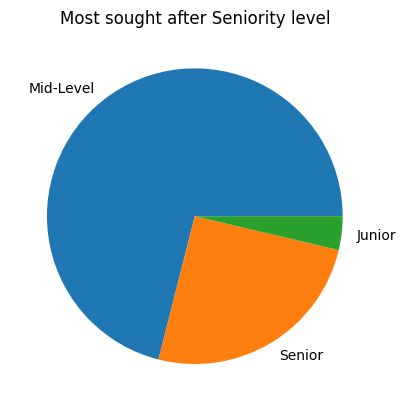

In [5]:
sen_count = df['Level'].value_counts()
seniority = df['Level'].value_counts().index
plt.pie(sen_count, labels=seniority)
plt.title("Most sought after Seniority level")
plt.show()

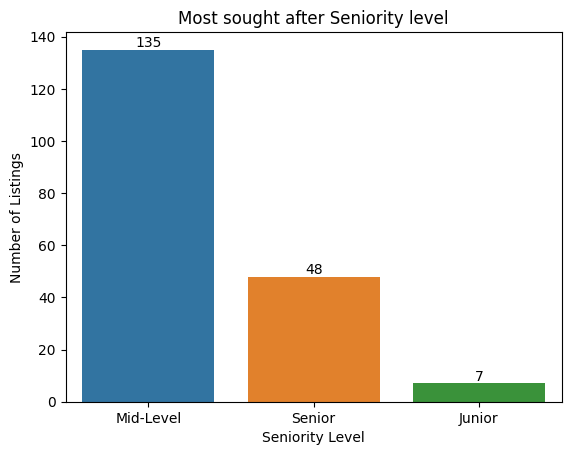

In [6]:
sen_lev_plot = sns.countplot(data=df, x='Level', hue='Level', order=df['Level'].value_counts().index)
for container in sen_lev_plot.containers:
    sen_lev_plot.bar_label(container)
plt.title("Most sought after Seniority level")
plt.xlabel("Seniority Level")
plt.ylabel("Number of Listings")
plt.show()

### 135 mid-level, 48 senior and 7 junior. That's a tough market for someone just starting out. Only 3.68% of listings are entry level. The Western Cape data market expects prior experience and junior roles are scarce. Candidates without experience should consider internships, freelance projects, or building a portfolio to bridge the gap.

---
## 2. Role Category Distribution
### What types of data roles are most in demand?

The raw `Title` column contains over 80 unique job titles, which is too granular to analyse meaningfully. We group them into broader categories (like Analyst, Engineer, Data Scientist, etc.) using keyword matching on the title. This allows us to compare role families at a market level.

In [7]:
df['Title'].value_counts()[:60]

Title
Data Analyst                                                              5
Senior Data Engineer                                                      5
Business Intelligence Analyst                                             4
FinOps Analyst                                                            2
Yield Analyst                                                             2
Business Process Analyst                                                  2
Senior Data Analyst                                                       2
Data Engineer                                                             2
Quantitative Analyst                                                      2
Data Scientist                                                            2
Machine Learning Engineer                                                 2
Lead Machine Learning Engineer                                            2
Lead Data Scientist                                                       2
Analys

### To tackle this, I am using Numpy to group all the Data Analysts, Data Scientists, Data Engineers & Architects together in their respective fields. Then adding them as a new Column called 'Category':

In [8]:
conditions = [
    df['Title'].str.contains('analyst', case=False, na=False),
    df['Title'].str.contains('scientist', case=False, na=False),
    df['Title'].str.contains('engineer', case=False, na=False),
    df['Title'].str.contains('architect', case=False, na=False)]

choices = [
    'Analyst',
    'Data Scientist',
    'Engineer',
    'Data Architect']
# Important to note: Order matters. If a title matches two conditions, it gets the label of whichever condition comes first!!! 
df['Category'] = np.select(conditions, choices, default='Other')

### Making sure the grouping worked and was added to the DataFrame: 

In [9]:
df[:60]

,Search Word,Website,Title,Company,Remote,Date Posted,Location,City,Level,Job Type,Description,Category
0,Data Analyst,indeed,Claims Risk Analyst,Momentum Health,False,2026-06-12,Bellville,Cape Town,Mid-Level,Unknown,Introduction Through our client-facing brands ...,Analyst
1,Data Analyst,indeed,Senior Application Support Analyst (SQL-focused),MRI Software,False,2026-06-12,Cape Town,Cape Town,Senior,Full-Time,MRI Software is seeking a Senior Application S...,Analyst
2,Data Analyst,indeed,Business Intelligence Analyst,LekkeSlaap,True,2026-06-12,Cape Town,Cape Town,Mid-Level,Full-Time,Bring 3+ years of proven experience in busines...,Analyst
3,Data Analyst,indeed,Technical Product Analyst,Sanlam,False,2026-06-12,Bellville,Cape Town,Mid-Level,Unknown,Who are we? Sanlam Life and Savings (SLS) is f...,Analyst
4,Data Analyst,indeed,Utilities Analyst,FPG Property Management,False,2026-06-12,Cape Town,Cape Town,Mid-Level,Full-Time,PURPOSE OF JOB The Utilities Analyst is respon...,Analyst
5,Data Analyst,indeed,Data Integrations Specialist - Client Focus,Healix Group of Companies,False,2026-06-12,Cape Town,Cape Town,Mid-Level,Full-Time,About the role We’re looking for a Data Integr...,Other
6,Data Analyst,indeed,Senior BI Analyst - Team Leader,Auto Trader South Africa,True,2026-06-12,Nuweland,Cape Town,Senior,Unknown,Senior BI Analyst - Team Leader Remote We're l...,Analyst
7,Data Analyst,indeed,Domain / Product owner - HR systems,Unifi,False,2026-06-12,Stellenbosch,Stellenbosch,Mid-Level,Unknown,About Unifi Boldly different. Fiercely human. ...,Other
8,Data Analyst,indeed,Data Analyst,Crisis24,False,2026-06-11,Cape Town,Cape Town,Mid-Level,Full-Time,Who We Are Looking For The Data Analyst resear...,Analyst
9,Data Analyst,indeed,Customer Success Reporting Analyst,Mama Money,False,2026-06-11,Cape Town,Cape Town,Mid-Level,Full-Time,Who we are: Mama Money is a growth-stage finte...,Analyst


#### Great! Now to count them all together:

In [10]:
df['Category'].value_counts()

Category
Analyst           92
Engineer          64
Other             14
Data Scientist    12
Data Architect     8
Name: count, dtype: int64

### Finding
Analysts make up the largest share of listings by a significant margin. This tells us the Western Cape data market prioritises roles focused on interpreting and communicating data over roles that build data infrastructure. For someone entering the field, analyst roles represent the most accessible entry point in this region.

## Displaying the distribution of Job Roles to visually represent what the data is saying:

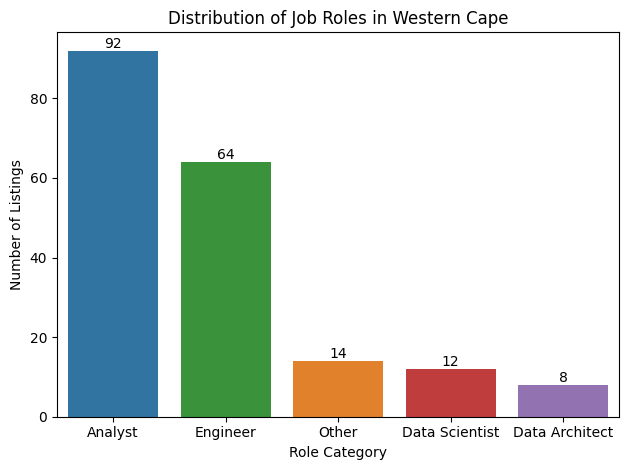

In [11]:
category_plot = sns.countplot(data=df, x='Category', hue='Category', order=df['Category'].value_counts().index)
for container in category_plot.containers:
    category_plot.bar_label(container)
plt.title("Distribution of Job Roles in Western Cape")
plt.xlabel("Role Category")
plt.ylabel("Number of Listings")
plt.tight_layout() # Spacing between xlabels.
plt.show()

### This is proof that Analysts and Engineers are the MOST sought after in June 2026, Western Cape, South Africa.

---
## 3. Top Hiring Companies
### Which companies are most actively recruiting data talent?

We look at the top 10 companies by listing count. An important distinction to note: some of the top results are recruitment agencies posting on behalf of unnamed clients, rather than direct employers.

In [12]:
df.Company.value_counts()

Company
ExecutivePlacements.com    16
Agoda                       9
Capitec                     8
Sanlam                      6
impact.com                  5
                           ..
Shoprite Holdings Ltd       1
OLX                         1
Meltwater                   1
TM Forum                    1
Tiko                        1
Name: count, Length: 125, dtype: int64

### ExecutivePlacements.com has 16 listings, but they're a recruitment agency, not a direct employer. The insight here is that a large portion of listings are posted by recruiters on behalf of unnamed companies, which means the actual employer market is more concentrated than it appears. Capitec and Sanlam are the standout direct employers.

### As visually shown down below:

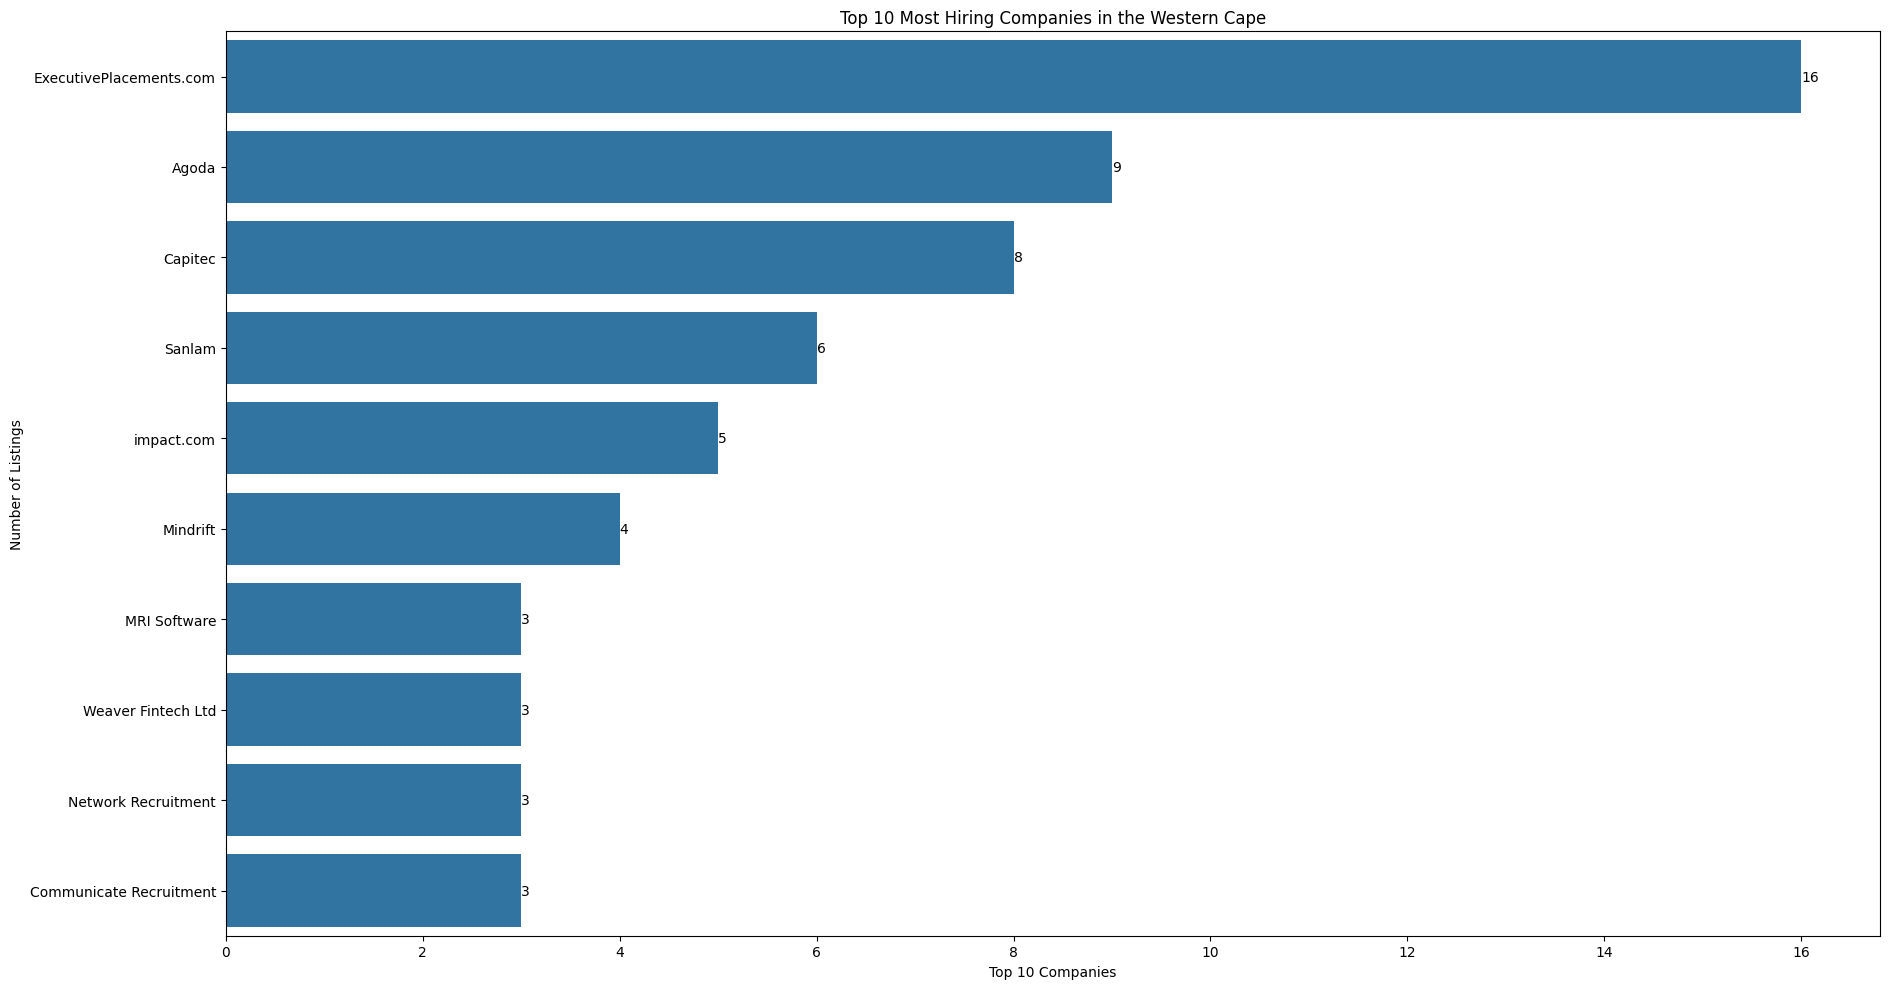

In [59]:
top_10_comp = df['Company'].value_counts().head(10)
plt.figure(figsize=(19, 10))
barplot = sns.barplot(x=top_10_comp.values, y=top_10_comp.index) # Top 10 companies.
for container in barplot.containers:
    barplot.bar_label(container)
plt.title('Top 10 Most Hiring Companies in the Western Cape')
plt.xlabel("Top 10 Companies")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.show()

---
## 4. Remote Work Availability
### How flexible is the Western Cape data job market?

We check how many of the 190 listings explicitly offer remote work. This is a important finding for candidates who are not based in Cape Town or who prefer flexible arrangements.

In [14]:
df['Remote'].value_counts()

Remote
False    179
True      11
Name: count, dtype: int64

### Only 11 remote listings out of 190 which is less than 6% (5.79%). The WC data job market is overwhelmingly for the on-site job type. That's a meaningful finding for anyone job hunting remotely.

---
## 5. Location Distribution
### Where in the Western Cape are data jobs concentrated?

We analyse job listings by city to understand geographic concentration. Two charts are used: total listings per city and a breakdown of remote vs on-site per city. It reveals whether remote flexibility varies by location.

### Chart 1 - How many listings per city:

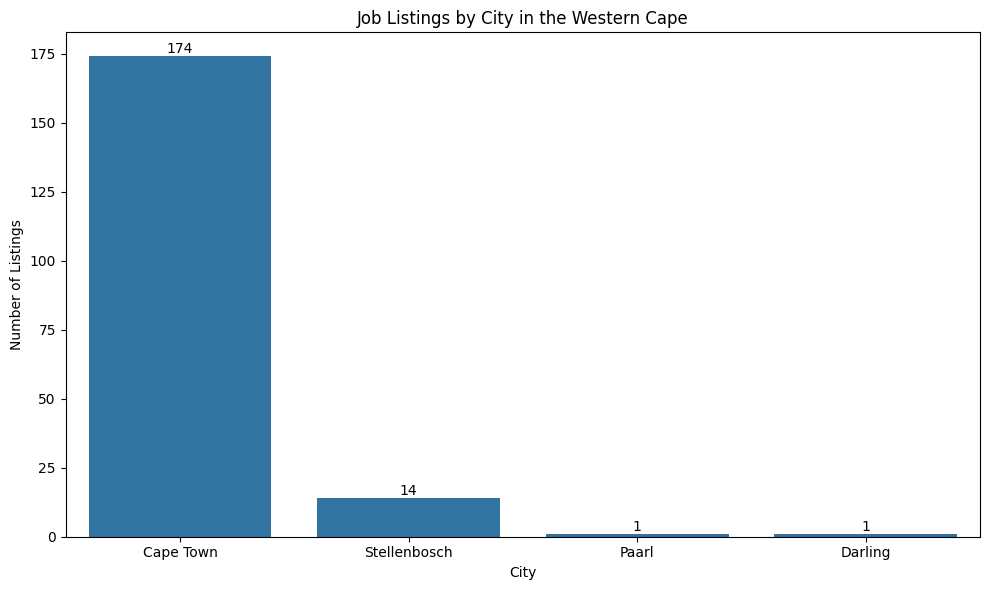

In [47]:
plt.figure(figsize=(10, 6))
loc_plot = sns.countplot(data=df, x='City', order=df['City'].value_counts().index)
for container in loc_plot.containers:
    loc_plot.bar_label(container)
plt.title('Job Listings by City in the Western Cape')
plt.xlabel('City')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.show()

### Chart 2 - Remote vs On-site per city:

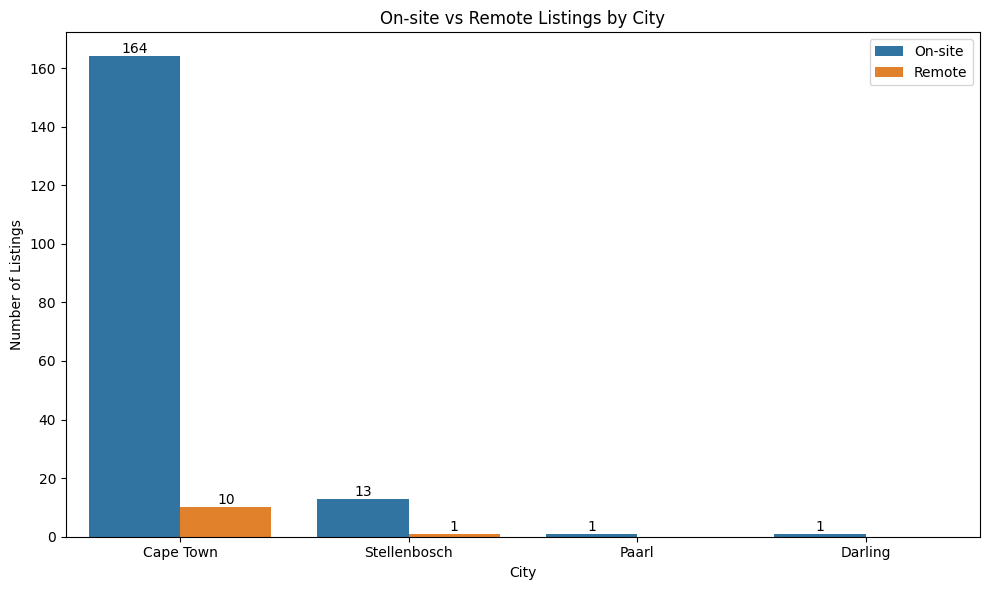

In [46]:
plt.figure(figsize=(10, 6))
loc_remote = sns.countplot(data=df, x='City', hue='Remote', order=df['City'].value_counts().index)
for container in loc_remote.containers:
    loc_remote.bar_label(container)
plt.title('On-site vs Remote Listings by City')
plt.xlabel('City')
plt.ylabel('Number of Listings')
plt.legend(labels=['On-site', 'Remote'])
plt.tight_layout()
plt.show()

### Finding
Cape Town is overwhelmingly the dominant hub for data roles in the Western Cape, accounting for over 91% of all listings. Stellenbosch is a distant second, driven largely by Capitec's headquarters being based there. Paarl and Darling together account for fewer than 5 listings. Remote opportunities are minimal across all cities, meaning physical location remains a real barrier to entry for most data candidates in this region.

---
## 6. Skills Analysis
### What technical tools and technologies do employers actually ask for?

This is the most actionable analysis in the project. We scan every job description for mentions of specific tools and technologies, counting how many listings reference each skill at least once. The result is a ranked view of what the market currently values.

**Method:** Each skill is checked independently using `str.contains()`. A case-insensitive keyword search across the `Description` column. A single listing can contribute to multiple skill counts, since most roles require more than one tool.

**Skills searched:** SQL, Python, Power BI, Tableau, Excel, R, AWS, Azure, Spark, Machine Learning, Git, dbt, Airflow, Google Analytics

In [61]:
skills = ['SQL', 'Python', 'Power BI', 'Tableau', 'Excel', 
          'AWS', 'Azure', 'Spark', 'Machine Learning', 
          'Git', 'Tableau', 'dbt', 'Airflow']

skill_count={}

# For every skill in skills list, iterate through description for all iterations and store in dictionary.
for skill in skills:
    count = df['Description'].str.contains(skill, case=False, na=False).sum() # Return True (1) or False (0), .sum() = Count all Trues [1+1+1...].
    # Store 'key' -> '[skill]' in dictionary. E.g. "Python" : 4
    skill_count[skill] = count

skills_data = pd.DataFrame(list(skill_count.items()), columns=['Skills','Count'])
print(skills_data)

              Skills  Count
0                SQL     29
1             Python     17
2           Power BI      9
3            Tableau      6
4              Excel     45
5                AWS     15
6              Azure     15
7              Spark      4
8   Machine Learning      6
9                Git     21
10               dbt      1
11           Airflow      1


In [62]:
skills_data = skills_data.sort_values('Count',ascending=True)
skills_data

,Skills,Count
10,dbt,1
11,Airflow,1
7,Spark,4
3,Tableau,6
8,Machine Learning,6
2,Power BI,9
6,Azure,15
5,AWS,15
1,Python,17
9,Git,21


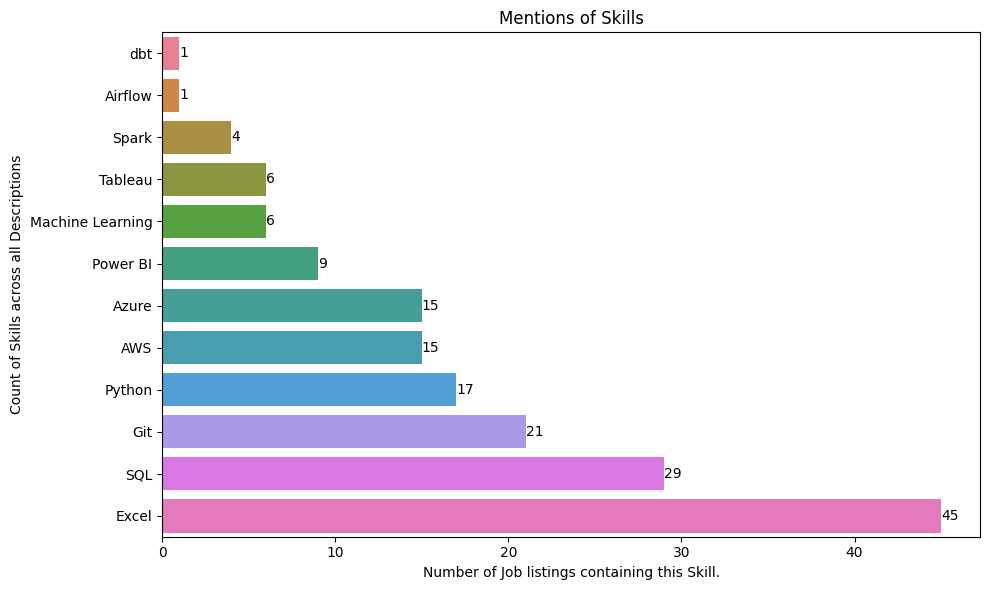

In [63]:
plt.figure(figsize=[10, 6])
skills_graph = sns.barplot(data=skills_data, x='Count', y='Skills', hue='Skills')
for container in skills_graph.containers:
    skills_graph.bar_label(container)
plt.title("Mentions of Skills")
plt.xlabel("Number of Job listings containing this Skill.")
plt.ylabel("Count of Skills across all Descriptions")
plt.tight_layout()

### Findings & Limitation

The chart above reveals the most frequently mentioned tools across Western Cape data job listings from June 2026. SQL and Python lead by a clear margin, confirming their status as the foundational skills for data roles in this market. Microsoft tools (Power BI, Excel) rank highly, reflecting the corporate and financial services of many WC employers. Tools such as AWS, Azure, Airflow, dbt appear less frequently, which suggests these are valued but not yet required at this market level.

> **Limitation:** Keyword frequency in job descriptions is not a perfect method to analyze for skill importance. A skill mentioned once in passing counts the same as one listed as a core requirement. This analysis is also bounded by our predefined skill list, tools not included (such as SAS, Looker, or MATLAB) would not appear in results even if present in the data. These findings should be interpreted as a general market signal, not a definitive skills ranking.

---
## Summary of Key Findings

| Finding | Detail |
|---|---|
| Most in-demand role | Analyst (by significant margin) |
| Dominant seniority | Mid-Level (71% of listings) |
| Junior opportunities | Scarce (only 7 listings (4%)) |
| Top direct employer | Capitec & Sanlam |
| Top listing source | ExecutivePlacements.com (recruitment agency) |
| Remote availability | Only 11 listings (5.8%) |
| Geographic concentration | Cape Town (91% of all listings) |
| Most mentioned skill | Excel |
| Second most mentioned | Python |

### What this means for a job seeker in the Western Cape
The WC data market is concentrated in Cape Town, skews mid-level and strongly favours candidates with SQL and Python skills. Remote opportunities are rare and junior roles are scarce. Making a strong portfolio and demonstrable project experience critical for breaking into the market without prior experience.